In [1]:
# Importing neccesary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import os
import warnings
warnings.filterwarnings("ignore")

os.listdir('../data')


['smartphones.csv']

In [2]:
# Reading the dataset
dataset = pd.read_csv("../data/smartphones.csv")
data_copia = dataset.copy()
dataset.sample(5)

,Smartphone,Brand,Model,RAM,Storage,Color,Free,Final Price
886,Samsung Galaxy S8 64GB Plata Libre versión esp...,Samsung,Galaxy S8,NaN,64.0,Silver,Yes,271.42
730,Xiaomi PocoPhone X3 Pro 6/128GB Azul Helado Libre,Xiaomi,X3,6.0,128.0,Blue,Yes,361.71
910,OPPO Find X3 Lite 8/128GB Azul Libre,OPPO,X3,8.0,128.0,Blue,Yes,469.00
399,Xiaomi Redmi 10 5G 4/128GB Gris Grafito Libre,Xiaomi,Redmi 10,4.0,128.0,Gray,Yes,169.94
1354,Gigaset GX290 Plus 4/64GB Negro Libre,Gigaset,GX290,4.0,64.0,Black,Yes,275.50


In [3]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1816 entries, 0 to 1815
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Smartphone   1816 non-null   str    
 1   Brand        1816 non-null   str    
 2   Model        1816 non-null   str    
 3   RAM          1333 non-null   float64
 4   Storage      1791 non-null   float64
 5   Color        1816 non-null   str    
 6   Free         1816 non-null   str    
 7   Final Price  1816 non-null   float64
dtypes: float64(3), str(5)
memory usage: 113.6 KB


In [4]:
dataset.describe()

,RAM,Storage,Final Price
count,1333.00000,1791.000000,1816.000000
mean,5.96099,162.652150,492.175573
std,2.66807,139.411605,398.606183
min,1.00000,2.000000,60.460000
25%,4.00000,64.000000,200.990000
50%,6.00000,128.000000,349.990000
75%,8.00000,256.000000,652.717500
max,12.00000,1000.000000,2271.280000


In [5]:
print(dataset["Storage"].value_counts())
print("-------------------------------")
print(dataset["RAM"].value_counts())

Storage
128.0     732
256.0     412
64.0      332
32.0      166
512.0      94
16.0       24
1000.0     17
4.0         6
8.0         3
2.0         2
3.0         2
12.0        1
Name: count, dtype: int64
-------------------------------
RAM
8.0     381
4.0     380
6.0     259
3.0     112
12.0    109
2.0      88
1.0       4
Name: count, dtype: int64


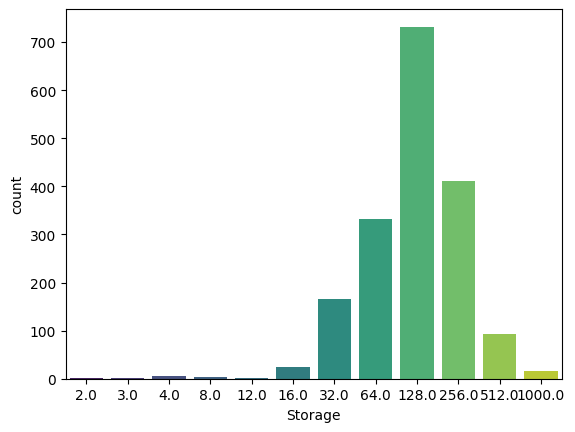

In [6]:
# Storage distribution
s_Storage = sns.countplot(x="Storage", data=dataset, palette="viridis")


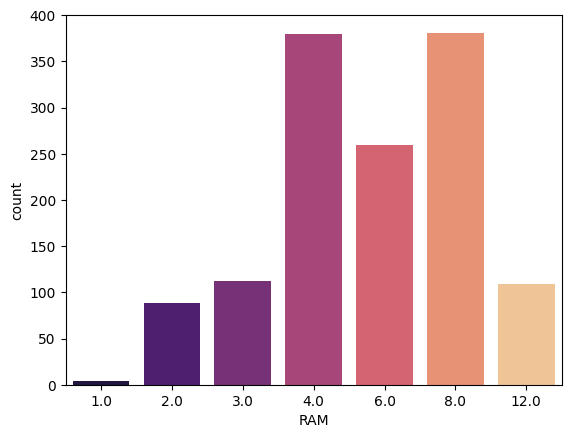

In [7]:
# RAM distribution
s_RAM = sns.countplot(x="RAM", data=dataset, palette="magma")

In [8]:
# Defining a function to check missing values. It will return the total and percentage of missing values in each column.
def missing_values(dataset):
    total = dataset.isnull().sum().sort_values(ascending=False)
    percent = (dataset.isnull().sum()/dataset.isnull().count()).sort_values(ascending=False)
    return pd.concat([total, percent], axis=1, keys=["Total", "Percent"])

missing_values(dataset)

,Total,Percent
RAM,483,0.265969
Storage,25,0.013767
Brand,0,0.000000
Smartphone,0,0.000000
Model,0,0.000000
Color,0,0.000000
Free,0,0.000000
Final Price,0,0.000000


In [9]:
# Imputing missing values using SimpleImputer
imputer = SimpleImputer(strategy="most_frequent")
dataset[["Storage", "RAM"]] = imputer.fit_transform(dataset[["Storage", "RAM"]])
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1816 entries, 0 to 1815
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Smartphone   1816 non-null   str    
 1   Brand        1816 non-null   str    
 2   Model        1816 non-null   str    
 3   RAM          1816 non-null   float64
 4   Storage      1816 non-null   float64
 5   Color        1816 non-null   str    
 6   Free         1816 non-null   str    
 7   Final Price  1816 non-null   float64
dtypes: float64(3), str(5)
memory usage: 113.6 KB


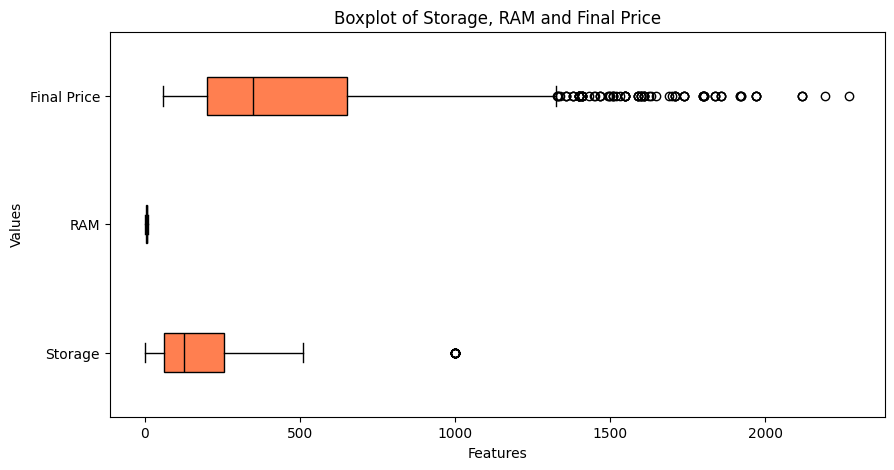

In [10]:
# Visualizing the outliers using boxplots
plt.figure(figsize=(10, 5))
plt.boxplot(dataset[["Storage", "RAM", "Final Price"]], vert=False, patch_artist=True, labels=["Storage", "RAM", "Final Price"], boxprops=dict(facecolor="coral", color="black"), medianprops=dict(color="black"), whiskerprops=dict(color="black"), capprops=dict(color="black"))
plt.title("Boxplot of Storage, RAM and Final Price")
plt.xlabel("Features")
plt.ylabel("Values")
plt.show()


In [11]:
# Removing outliers using IQR method
Q1 = dataset[["Storage", "Final Price"]].quantile(0.25)
Q3 = dataset[["Storage", "Final Price"]].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
dataset = dataset[~((dataset[["Storage", "Final Price"]] < lower_bound) | (dataset[["Storage", "Final Price"]] > upper_bound)).any(axis=1)]   
dataset.info()

<class 'pandas.DataFrame'>
Index: 1721 entries, 0 to 1815
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Smartphone   1721 non-null   str    
 1   Brand        1721 non-null   str    
 2   Model        1721 non-null   str    
 3   RAM          1721 non-null   float64
 4   Storage      1721 non-null   float64
 5   Color        1721 non-null   str    
 6   Free         1721 non-null   str    
 7   Final Price  1721 non-null   float64
dtypes: float64(3), str(5)
memory usage: 121.0 KB


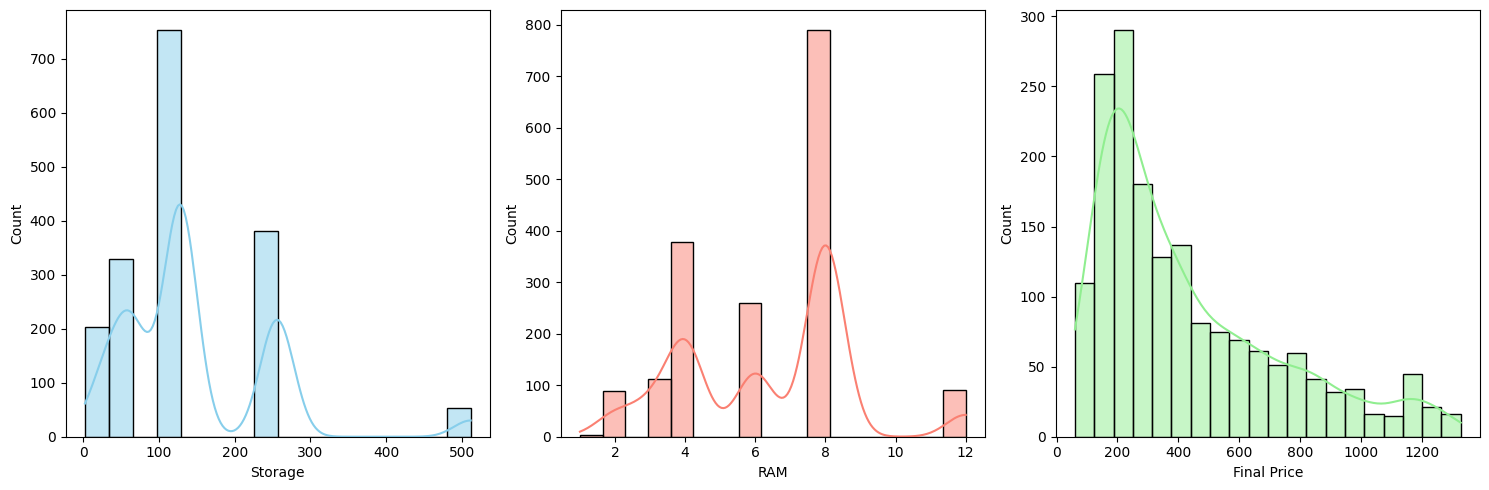

In [12]:
# Understanding if the data is skewed or not using histograms
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(dataset["Storage"], kde=True, color="skyblue")
plt.subplot(1, 3, 2)
sns.histplot(dataset["RAM"], kde=True, color="salmon")
plt.subplot(1, 3, 3)
sns.histplot(dataset["Final Price"], kde=True, color="lightgreen")
plt.tight_layout()
plt.show()

In [13]:
dataset[["Storage", "RAM", "Final Price"]].skew()

Storage        1.583319
RAM            0.076765
Final Price    1.129954
dtype: float64

In [14]:
# Managing the skewness of the data using log transformation
dataset["Final Price"] = np.log1p(dataset["Final Price"])
dataset["Storage"] = np.log1p(dataset["Storage"])
dataset[["Storage", "RAM", "Final Price"]].skew()


Storage       -0.800742
RAM            0.076765
Final Price    0.111547
dtype: float64

In [15]:
# Change the column free into boolean values
dataset["Free"] = dataset["Free"].map({"Yes": 1, "No": 0})

In [16]:
# Dealing with Model using frequency encoding
dataset["Model"] = dataset["Model"].map(dataset["Model"].value_counts())

In [18]:
# Use frequency encoding for the smartphone column and create new binary features for common keywords in the smartphone names. 
# Then drop the original smartphone column.
dataset["Smartphone_Freq"] = dataset["Smartphone"].map(dataset["Smartphone"].value_counts())
dataset["is_pro"] = dataset["Smartphone"].str.contains("Pro", case=False).astype(int)
dataset["is_plus"] = dataset["Smartphone"].str.contains("Plus", case=False).astype(int)
dataset["is_max"] = dataset["Smartphone"].str.contains("Max", case=False).astype(int)
dataset["is_mini"] = dataset["Smartphone"].str.contains("Mini", case=False).astype(int)
dataset["is_ultra"] = dataset["Smartphone"].str.contains("Ultra", case=False).astype(int)
dataset["is_lite"] = dataset["Smartphone"].str.contains("Lite", case=False).astype(int)
dataset["name_length"] = dataset["Smartphone"].str.split().str.len()
dataset.drop("Smartphone", axis=1, inplace=True)

In [19]:
# Manage brand and Color columns using one-hot encoding
dataset = pd.get_dummies(dataset, columns=["Brand", "Color"], drop_first=True)
dataset.info()

<class 'pandas.DataFrame'>
Index: 1721 entries, 0 to 1815
Data columns (total 65 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Model             1721 non-null   int64  
 1   RAM               1721 non-null   float64
 2   Storage           1721 non-null   float64
 3   Free              1721 non-null   int64  
 4   Final Price       1721 non-null   float64
 5   Smartphone_Freq   1721 non-null   int64  
 6   is_pro            1721 non-null   int64  
 7   is_plus           1721 non-null   int64  
 8   is_max            1721 non-null   int64  
 9   is_mini           1721 non-null   int64  
 10  is_ultra          1721 non-null   int64  
 11  is_lite           1721 non-null   int64  
 12  name_length       1721 non-null   int64  
 13  Brand_Apple       1721 non-null   bool   
 14  Brand_Asus        1721 non-null   bool   
 15  Brand_BQ          1721 non-null   bool   
 16  Brand_Blackview   1721 non-null   bool   
 17  Brand_CAT  

In [ ]:
dataset.to_csv("../data/smartphones_cleaned.csv", index=False) # Save the cleaned dataset to a new CSV file
